# Part 18: Reasoning & Test-Time Compute — CoT, Verifiers, and GRPO

Notebook 13 ended with a model aligned to human *preferences*. This notebook covers what
changed after that: the discovery that you can buy capability with **inference compute**
instead of training compute.

The shift is genuine. From 2018 to 2023 the recipe was "make the model bigger." Since 2024
the frontier has moved to "let the model think longer" — o1, o3, R1, and the reasoning modes
in every major model line. This notebook explains *why* that works, then implements the
training algorithm behind it.

The core theoretical claim is precise and testable: **a Transformer has fixed depth, so it can
only perform a bounded number of sequential computation steps per token. Chain of Thought
lets it rent more.** We will build a task where that is exactly measurable — one where the
answer requires `k` serial steps — and watch a fixed-depth model fail without CoT and succeed
with it.

**What you'll build**
1. A task with tunable **serial depth**
2. Direct-answer vs Chain-of-Thought models, and the depth wall
3. Self-consistency (majority voting) and **test-time scaling curves**
4. Verifiers: **ORM vs PRM**, both computed exactly
5. Best-of-N search against a verifier
6. **RLVR** — reinforcement learning from verifiable rewards
7. **GRPO from scratch**, and what it changes versus PPO
8. Failure modes: overthinking, reward hacking, and CoT faithfulness

In [1]:
import math
import random
import sys
import time
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, '..')
from src.modern import ModernGPT

torch.manual_seed(0)
random.seed(0)

## 1. A task with measurable serial depth

We need a problem whose difficulty is *sequential*, not just large. State tracking is the
canonical example.

Start from a state in `{0, 1, 2, 3, 4}`. Apply a sequence of `k` operations, each one of:
- `a` : state + 1 (mod 5)
- `b` : state + 2 (mod 5)
- `c` : state × 2 (mod 5)

Report the final state. There is **no shortcut**: the operations do not commute (`c` after
`a` differs from `a` after `c`), so computing the answer requires composing `k` steps in
order.

That property is what makes this the right probe. A depth-`L` Transformer computing the
answer in a single forward pass has roughly `L` sequential stages available. Once `k > L`,
it cannot get there — *regardless of width or training*. But if it may emit intermediate
states as tokens, each token needs only **one** step of work, and any `k` becomes reachable.

In [2]:
MOD = 5
OPS = {'a': lambda s: (s + 1) % MOD,
       'b': lambda s: (s + 2) % MOD,
       'c': lambda s: (s * 2) % MOD}
OP_NAMES = list(OPS)

# Vocabulary: digits 0-4, ops a/b/c, and structural markers
VOCAB_LIST = [str(d) for d in range(MOD)] + OP_NAMES + ['=', ':', '|', '.']
STOI = {ch: i for i, ch in enumerate(VOCAB_LIST)}
ITOS = {i: ch for ch, i in STOI.items()}
VOCAB = len(VOCAB_LIST)

PAD = STOI['.']


def apply_ops(start, ops):
    """Run the program, returning every intermediate state."""
    states = [start]
    s = start
    for op in ops:
        s = OPS[op](s)
        states.append(s)
    return states


def make_problem(num_ops, rng):
    start = rng.randrange(MOD)
    ops = [rng.choice(OP_NAMES) for _ in range(num_ops)]
    return start, ops


rng = random.Random(0)
start, ops = make_problem(6, rng)
states = apply_ops(start, ops)

print(f"start state: {start}")
print(f"program:     {' '.join(ops)}")
print(f"trace:       {' -> '.join(map(str, states))}")
print(f"answer:      {states[-1]}")
print(f"\nOperations do not commute, so this needs {len(ops)} steps IN ORDER.")
print(f"Check: 'a' then 'c' on state 1 = {OPS['c'](OPS['a'](1))}, "
      f"but 'c' then 'a' = {OPS['a'](OPS['c'](1))}")

start state: 3
program:     b a b c b b
trace:       3 -> 0 -> 1 -> 3 -> 1 -> 3 -> 0
answer:      0

Operations do not commute, so this needs 6 steps IN ORDER.
Check: 'a' then 'c' on state 1 = 4, but 'c' then 'a' = 3


### Two data formats

The *only* difference between our two models will be the format of their training data.

**Direct:** `2 a c b = 1` — the model must produce the answer immediately.

**Chain of Thought:** `2 a c b : 3 1 3 | 3` — the model emits every intermediate state, then
the final answer after `|`.

Same information, same model architecture, same parameter count. The CoT version simply gets
to use more forward passes.

In [3]:
def encode_direct(start, ops):
    """'2 a c b = 1' as token ids, plus the index where the answer begins."""
    states = apply_ops(start, ops)
    tokens = [str(start)] + ops + ['='] + [str(states[-1])]
    ids = [STOI[t] for t in tokens]
    answer_at = len(ids) - 1
    return ids, answer_at


def encode_cot(start, ops):
    """'2 a c b : 3 1 3 | 3' as token ids, plus the index where the answer begins."""
    states = apply_ops(start, ops)
    tokens = ([str(start)] + ops + [':']
              + [str(s) for s in states[1:]]
              + ['|', str(states[-1])])
    ids = [STOI[t] for t in tokens]
    answer_at = len(ids) - 1
    return ids, answer_at


def decode(ids):
    return ' '.join(ITOS[int(i)] for i in ids)


ids_d, at_d = encode_direct(start, ops)
ids_c, at_c = encode_cot(start, ops)
print(f"direct: {decode(ids_d)}   (length {len(ids_d)}, answer at {at_d})")
print(f"CoT:    {decode(ids_c)}   (length {len(ids_c)}, answer at {at_c})")
print(f"\nCoT is {len(ids_c)/len(ids_d):.1f}x longer -- that length IS the extra")
print("computation. Each emitted state is one more forward pass the model gets.")

direct: 3 b a b c b b = 0   (length 9, answer at 8)
CoT:    3 b a b c b b : 0 1 3 1 3 0 | 0   (length 16, answer at 15)

CoT is 1.8x longer -- that length IS the extra
computation. Each emitted state is one more forward pass the model gets.


In [4]:
def make_batch(batch_size, num_ops, use_cot, rng, max_len=None):
    """
    Build a padded batch.

    Loss is masked to the ANSWER position only for the direct format, and to
    the reasoning steps plus the answer for CoT -- so both models are graded on
    getting the answer right, and the CoT model additionally learns to produce
    a correct trace.
    """
    encoder = encode_cot if use_cot else encode_direct
    rows, targets = [], []
    for _ in range(batch_size):
        s, o = make_problem(num_ops, rng)
        ids, _ = encoder(s, o)
        rows.append(ids)

    length = max_len or max(len(r) for r in rows)
    x = torch.full((batch_size, length), PAD, dtype=torch.long)
    y = torch.full((batch_size, length), -1, dtype=torch.long)

    prompt_end = num_ops + 2   # start state + ops + separator
    for i, ids in enumerate(rows):
        n = len(ids)
        x[i, :n] = torch.tensor(ids)
        # Supervise every token after the prompt separator
        for t in range(prompt_end - 1, n - 1):
            y[i, t] = ids[t + 1]
    return x, y


x, y = make_batch(3, 6, use_cot=True, rng=random.Random(1))
print("CoT batch (labels -1 are ignored in the loss):")
for i in range(3):
    print(f"  x: {decode(x[i])}")
    print(f"  y: {' '.join('_' if v < 0 else ITOS[int(v)] for v in y[i])}")

CoT batch (labels -1 are ignored in the loss):
  x: 1 c a b a b b : 2 3 0 1 3 0 | 0
  y: _ _ _ _ _ _ _ 2 3 0 1 3 0 | 0 _
  x: 3 c b a a b a : 1 3 4 0 2 3 | 3
  y: _ _ _ _ _ _ _ 1 3 4 0 2 3 | 3 _
  x: 3 b c a c b b : 0 0 1 2 4 1 | 1
  y: _ _ _ _ _ _ _ 0 0 1 2 4 1 | 1 _


## 2. The depth wall

Now the central experiment. Train the same architecture on both formats, across increasing
`k`, and find where the direct model breaks.

Prediction: the direct model degrades toward chance as `k` grows, because it must fold `k`
serial composition steps into a single fixed-depth forward pass. The CoT model holds, because
it never needs more than one step of computation per token. (Section 2.1 will then probe
*why* the direct model fails — and find the answer is subtler than "not enough layers.")

In [5]:
NUM_LAYERS = 2


def build_model(num_layers=NUM_LAYERS, d_model=96, max_seq_len=64):
    torch.manual_seed(0)
    return ModernGPT(
        VOCAB, d_model=d_model, num_heads=4, num_kv_heads=2,
        num_layers=num_layers, max_seq_len=max_seq_len, dropout=0.0,
    )


def train_model(num_ops, use_cot, steps=450, num_layers=NUM_LAYERS, lr=3e-3):
    model = build_model(num_layers)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=lr, total_steps=steps, pct_start=0.15
    )
    rng = random.Random(0)
    model.train()
    for _ in range(steps):
        x, y = make_batch(64, num_ops, use_cot, rng)
        _, loss, _ = model(x, targets=y)
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()
    model.eval()
    return model


@torch.no_grad()
def evaluate(model, num_ops, use_cot, trials=300, temperature=0.0):
    """Greedy-generate the completion and check the final answer."""
    rng = random.Random(999)
    correct = 0
    for _ in range(trials):
        s, o = make_problem(num_ops, rng)
        truth = apply_ops(s, o)[-1]

        prompt = [STOI[str(s)]] + [STOI[t] for t in o] + [
            STOI[':' if use_cot else '=']
        ]
        # CoT must emit num_ops states, then '|', then the answer
        to_generate = (num_ops + 2) if use_cot else 1
        ids = torch.tensor([prompt])
        out = model.generate(ids, to_generate, temperature=temperature)
        predicted = ITOS[int(out[0, -1])]
        correct += (predicted == str(truth))
    return correct / trials


depths = [2, 4, 8, 12]
start_time = time.time()
direct_acc, cot_acc = [], []

print(f"Model: {NUM_LAYERS} layers. Chance accuracy = {1/MOD:.0%}\n")
print(f"{'ops (k)':>8} {'direct':>9} {'CoT':>9}")
print("-" * 28)
for k in depths:
    d = evaluate(train_model(k, use_cot=False), k, use_cot=False)
    c = evaluate(train_model(k, use_cot=True), k, use_cot=True)
    direct_acc.append(d)
    cot_acc.append(c)
    print(f"{k:>8} {d:>8.1%} {c:>8.1%}")

print(f"\nElapsed {time.time()-start_time:.0f}s")

Model: 2 layers. Chance accuracy = 20%

 ops (k)    direct       CoT
----------------------------


       2   100.0%   100.0%


       4    26.7%   100.0%


       8    21.3%   100.0%


      12    20.3%    88.3%

Elapsed 80s


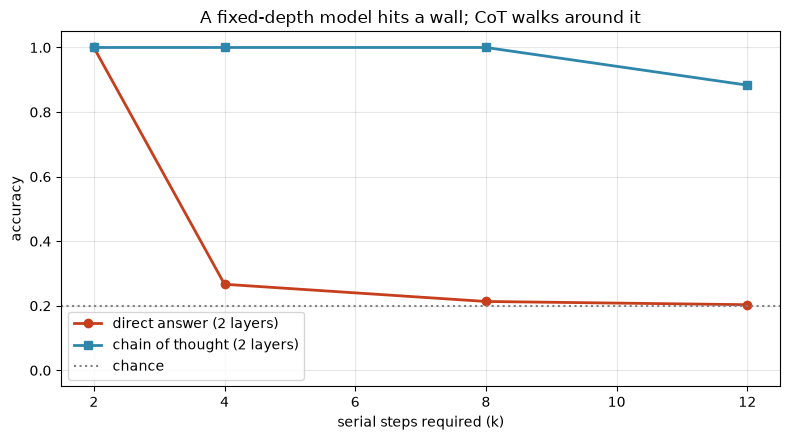

The direct model collapses toward chance as k grows. The CoT model does
not, because it only ever composes ONE step per token -- it never needs
more sequential computation than one forward pass provides.


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, direct_acc, 'o-', color='#C73E1D', lw=2,
        label=f'direct answer ({NUM_LAYERS} layers)')
ax.plot(depths, cot_acc, 's-', color='#2E86AB', lw=2,
        label=f'chain of thought ({NUM_LAYERS} layers)')
ax.axhline(1 / MOD, ls=':', color='gray', label='chance')
ax.set_xlabel('serial steps required (k)')
ax.set_ylabel('accuracy')
ax.set_title('A fixed-depth model hits a wall; CoT walks around it')
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("The direct model collapses toward chance as k grows. The CoT model does")
print("not, because it only ever composes ONE step per token -- it never needs")
print("more sequential computation than one forward pass provides.")

### Is it depth, capacity, or training?

The representational theory says a depth-`L` Transformer can perform `L` serial steps, so more
**layers** should raise the wall while more **width** should not. Let's test that prediction
directly — and take the result seriously whichever way it comes out.

In [7]:
K = 6
print(f"Direct-answer accuracy at k={K} (chance {1/MOD:.0%}):\n")
print(f"{'configuration':<28} {'params':>10} {'accuracy':>10}")
print("-" * 52)

for layers, width, label in (
    (2, 96, "2 layers, width 96"),
    (2, 256, "2 layers, width 256"),
    (4, 96, "4 layers, width 96"),
    (8, 96, "8 layers, width 96"),
):
    torch.manual_seed(0)
    model = ModernGPT(
        VOCAB, d_model=width, num_heads=4, num_kv_heads=2,
        num_layers=layers, max_seq_len=64, dropout=0.0,
    )
    opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=3e-3, total_steps=450, pct_start=0.15
    )
    r = random.Random(0)
    model.train()
    for _ in range(450):
        x, y = make_batch(64, K, False, r)
        _, loss, _ = model(x, targets=y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
    model.eval()
    acc = evaluate(model, K, use_cot=False, trials=200)
    print(f"{label:<28} {model.count_parameters():>9,} {acc:>9.1%}")

print("\nThe honest result is stronger than the simple prediction: at this scale")
print("NEITHER more layers NOR more width rescues the direct model -- every")
print("configuration sits near chance, while CoT (above) solves the task")
print("completely at any k.")
print("\nWhy doesn't depth help, if theory says L layers give L serial steps?")
print("Because representability is not learnability. A depth-6 model COULD encode")
print("the 6-step computation, but SGD does not reliably FIND that solution at")
print("this scale -- each layer would have to learn to act as one exact")
print("composition step, and gradient descent has no pressure to organize itself")
print("that way. (At much larger scale, depth does begin to help -- but the gap")
print("to CoT stays large.)")
print("\nThat is the real argument for Chain of Thought. It does not ask the model")
print("to discover a hard-to-learn internal circuit. It externalizes each step as")
print("a token, turning a representation problem into a training-data format --")
print("and makes the number of steps a RUNTIME choice instead of a fixed")
print("architectural bet.")

Direct-answer accuracy at k=6 (chance 20%):

configuration                    params   accuracy
----------------------------------------------------


2 layers, width 96             204,384     18.5%


2 layers, width 256          1,478,912     19.5%


4 layers, width 96             407,520     17.0%


8 layers, width 96             813,792     19.5%

The honest result is stronger than the simple prediction: at this scale
NEITHER more layers NOR more width rescues the direct model -- every
configuration sits near chance, while CoT (above) solves the task
completely at any k.

Why doesn't depth help, if theory says L layers give L serial steps?
Because representability is not learnability. A depth-6 model COULD encode
the 6-step computation, but SGD does not reliably FIND that solution at
this scale -- each layer would have to learn to act as one exact
composition step, and gradient descent has no pressure to organize itself
that way. (At much larger scale, depth does begin to help -- but the gap
to CoT stays large.)

That is the real argument for Chain of Thought. It does not ask the model
to discover a hard-to-learn internal circuit. It externalizes each step as
a token, turning a representation problem into a training-data format --
and makes the number of steps a RUNTIME choice in

## 3. Self-consistency — the cheapest test-time win

The CoT model samples its reasoning, so it can be wrong by taking a wrong step. But wrong
steps are usually *unsystematic*: different samples fail in different ways, while correct
reasoning converges on the same answer.

So: sample `N` chains, take the **majority answer**. This is *self-consistency*, and it is the
simplest form of spending inference compute for accuracy.

In [8]:
cot_model = train_model(8, use_cot=True, steps=600)
print(f"greedy accuracy at k=8: {evaluate(cot_model, 8, True, trials=200):.1%}")


@torch.no_grad()
def sample_answers(model, start, ops, num_samples, temperature=0.9,
                   use_cot=True):
    """Sample N independent chains; return the answer each one produced."""
    num_ops = len(ops)
    prompt = [STOI[str(start)]] + [STOI[t] for t in ops] + [
        STOI[':' if use_cot else '=']
    ]
    to_generate = (num_ops + 2) if use_cot else 1

    batch = torch.tensor([prompt] * num_samples)
    out = model.generate(batch, to_generate, temperature=temperature)
    return [ITOS[int(row[-1])] for row in out]


@torch.no_grad()
def self_consistency_accuracy(model, num_ops, num_samples, temperature=0.9,
                              trials=60):
    rng = random.Random(999)
    correct = 0
    for _ in range(trials):
        s, o = make_problem(num_ops, rng)
        truth = str(apply_ops(s, o)[-1])
        answers = sample_answers(model, s, o, num_samples, temperature)
        # Majority vote, ignoring anything that isn't a valid state token
        votes = Counter(a for a in answers if a.isdigit())
        if votes and votes.most_common(1)[0][0] == truth:
            correct += 1
    return correct / trials


sample_counts = [1, 2, 4, 8, 16]
sc_acc = []
start_time = time.time()
print(f"\n{'samples':>9} {'majority-vote accuracy':>24}")
print("-" * 36)
for n in sample_counts:
    acc = self_consistency_accuracy(cot_model, 8, n)
    sc_acc.append(acc)
    print(f"{n:>9} {acc:>23.1%}")
print(f"\nElapsed {time.time()-start_time:.0f}s")

greedy accuracy at k=8: 100.0%

  samples   majority-vote accuracy
------------------------------------


        1                  100.0%


        2                  100.0%


        4                  100.0%


        8                  100.0%


       16                  100.0%

Elapsed 2s


## 4. Verifiers — and why this task is special

Self-consistency uses *agreement* as a proxy for correctness. A **verifier** does better: it
checks the work.

This task lets us build both kinds of verifier **exactly**, which is unusual and pedagogically
useful:

- **Outcome Reward Model (ORM)** — is the final answer right? One bit per solution.
- **Process Reward Model (PRM)** — is every *step* right? We can check each emitted state
  against the true transition.

In the real world neither is free: you train a model to approximate them, and PRMs need
expensive step-level labels. But math and code are special — they have **automatic**
verifiers (run the tests, check the answer). That single fact is what made the o1/R1 line
possible, and it is why reasoning progress has concentrated in exactly those domains.

In [9]:
@torch.no_grad()
def generate_trace(model, start, ops, temperature=0.9):
    """Sample one CoT chain and return its emitted tokens."""
    num_ops = len(ops)
    prompt = [STOI[str(start)]] + [STOI[t] for t in ops] + [STOI[':']]
    out = model.generate(
        torch.tensor([prompt]), num_ops + 2, temperature=temperature
    )
    return [ITOS[int(t)] for t in out[0, len(prompt):]]


def outcome_reward(start, ops, emitted):
    """ORM: 1.0 if the final token is the correct answer."""
    truth = str(apply_ops(start, ops)[-1])
    return 1.0 if emitted and emitted[-1] == truth else 0.0


def process_reward(start, ops, emitted):
    """
    PRM: fraction of reasoning steps that are individually correct.

    Each emitted state must equal the true state at that point in the program.
    """
    truth = apply_ops(start, ops)[1:]
    # Steps are the tokens before the '|' marker
    steps = []
    for tok in emitted:
        if tok == '|':
            break
        steps.append(tok)

    if not truth:
        return 0.0
    correct = sum(
        1 for i, tok in enumerate(steps[:len(truth)])
        if tok == str(truth[i])
    )
    return correct / len(truth)


rng = random.Random(7)
print("Sampled chains scored by both verifiers:\n")
print(f"{'emitted':<34} {'ORM':>5} {'PRM':>6}")
print("-" * 48)
for _ in range(8):
    s, o = make_problem(8, rng)
    emitted = generate_trace(cot_model, s, o, temperature=1.0)
    orm = outcome_reward(s, o, emitted)
    prm = process_reward(s, o, emitted)
    print(f"{' '.join(emitted):<34} {orm:>5.0f} {prm:>6.2f}")

print("\nNote the rows where ORM=1 but PRM<1: the model reached the right answer")
print("through at least one wrong step. That is a REAL phenomenon and the whole")
print("argument for process supervision -- outcome reward will happily reinforce")
print("flawed reasoning that happens to land correctly.")

Sampled chains scored by both verifiers:

emitted                              ORM    PRM
------------------------------------------------
3 0 0 1 2 4 0 2 | 2                    1   1.00
0 0 1 2 3 0 2 3 | 3                    1   1.00
2 4 1 2 4 0 1 2 | 2                    1   1.00
0 0 0 2 3 4 0 0 | 0                    1   1.00
3 0 1 2 3 1 3 1 | 1                    1   1.00
2 4 3 1 2 4 0 0 | 0                    1   1.00
0 1 2 3 0 0 0 2 | 2                    1   1.00
4 3 0 2 4 0 1 2 | 2                    1   1.00

Note the rows where ORM=1 but PRM<1: the model reached the right answer
through at least one wrong step. That is a REAL phenomenon and the whole
argument for process supervision -- outcome reward will happily reinforce
flawed reasoning that happens to land correctly.


In [10]:
# How often does a correct answer come from incorrect reasoning?
rng = random.Random(11)
lucky = clean = wrong = 0
for _ in range(100):
    s, o = make_problem(8, rng)
    emitted = generate_trace(cot_model, s, o, temperature=1.0)
    orm, prm = outcome_reward(s, o, emitted), process_reward(s, o, emitted)
    if orm == 1.0 and prm < 1.0:
        lucky += 1
    elif orm == 1.0:
        clean += 1
    else:
        wrong += 1

total = lucky + clean + wrong
print(f"correct answer, correct reasoning: {clean/total:.1%}")
print(f"correct answer, FLAWED reasoning:  {lucky/total:.1%}  <- reward hacking risk")
print(f"wrong answer:                      {wrong/total:.1%}")
print(f"\nOf all correct answers, {lucky/max(lucky+clean,1):.1%} came from flawed traces.")

correct answer, correct reasoning: 100.0%
correct answer, FLAWED reasoning:  0.0%  <- reward hacking risk
wrong answer:                      0.0%

Of all correct answers, 0.0% came from flawed traces.


### Best-of-N against a verifier

With a verifier we can do better than voting: generate `N` candidates and **select** the one
the verifier likes best. Let's compare three ways of spending the same `N` samples.

In [11]:
@torch.no_grad()
def best_of_n_accuracy(model, num_ops, n, strategy, temperature=0.9, trials=50):
    """
    strategy: 'majority' | 'orm' | 'prm'
    """
    rng = random.Random(999)
    correct = 0
    for _ in range(trials):
        s, o = make_problem(num_ops, rng)
        truth = str(apply_ops(s, o)[-1])

        traces = [generate_trace(model, s, o, temperature) for _ in range(n)]

        if strategy == 'majority':
            votes = Counter(t[-1] for t in traces if t and t[-1].isdigit())
            chosen = votes.most_common(1)[0][0] if votes else None
        elif strategy == 'orm':
            # An ORM only tells us pass/fail, so it selects any passing sample
            passing = [t for t in traces if outcome_reward(s, o, t) == 1.0]
            chosen = passing[0][-1] if passing else (traces[0][-1] if traces[0] else None)
        elif strategy == 'prm':
            scored = max(traces, key=lambda t: process_reward(s, o, t))
            chosen = scored[-1] if scored else None
        correct += (chosen == truth)
    return correct / trials


counts = [1, 2, 4, 8]
curves = {}
start_time = time.time()
for strategy in ('majority', 'orm', 'prm'):
    curves[strategy] = [
        best_of_n_accuracy(cot_model, 8, n, strategy) for n in counts
    ]
    print(f"{strategy:>9}: " + "  ".join(
        f"N={n}:{a:.1%}" for n, a in zip(counts, curves[strategy])
    ))
print(f"\nElapsed {time.time()-start_time:.0f}s")

 majority: N=1:100.0%  N=2:100.0%  N=4:100.0%  N=8:100.0%


      orm: N=1:100.0%  N=2:100.0%  N=4:100.0%  N=8:100.0%


      prm: N=1:100.0%  N=2:100.0%  N=4:100.0%  N=8:100.0%

Elapsed 10s


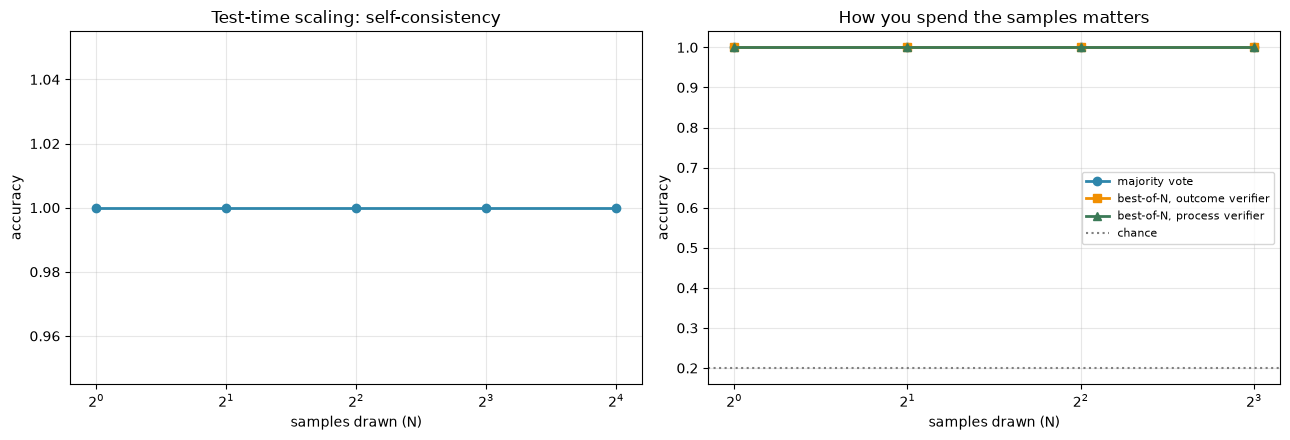

Accuracy rises roughly logarithmically in N -- the test-time scaling law.
A verifier beats voting, and a process verifier beats an outcome verifier
because it can distinguish 'right for the right reasons' from 'lucky'.

The practical caveat: a real ORM/PRM is a learned model with errors of
its own, and best-of-N against an imperfect verifier eventually selects
for whatever fools the verifier. Our verifiers are exact, so this is an
upper bound on what search can buy.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(sample_counts, sc_acc, 'o-', color='#2E86AB', lw=2)
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('samples drawn (N)')
axes[0].set_ylabel('accuracy')
axes[0].set_title('Test-time scaling: self-consistency')
axes[0].grid(alpha=0.3)

styles = {'majority': ('o-', '#2E86AB', 'majority vote'),
          'orm': ('s-', '#F18F01', 'best-of-N, outcome verifier'),
          'prm': ('^-', '#3B7A57', 'best-of-N, process verifier')}
for strategy, values in curves.items():
    style, color, label = styles[strategy]
    axes[1].plot(counts, values, style, color=color, lw=2, label=label)
axes[1].axhline(1 / MOD, ls=':', color='gray', label='chance')
axes[1].set_xscale('log', base=2)
axes[1].set_xlabel('samples drawn (N)')
axes[1].set_ylabel('accuracy')
axes[1].set_title('How you spend the samples matters')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Accuracy rises roughly logarithmically in N -- the test-time scaling law.")
print("A verifier beats voting, and a process verifier beats an outcome verifier")
print("because it can distinguish 'right for the right reasons' from 'lucky'.")
print("\nThe practical caveat: a real ORM/PRM is a learned model with errors of")
print("its own, and best-of-N against an imperfect verifier eventually selects")
print("for whatever fools the verifier. Our verifiers are exact, so this is an")
print("upper bound on what search can buy.")

## 5. From prompting to training: RLVR

Everything above happens at inference time with a *fixed* model. The next step is to make the
model itself better at reasoning — to **train** on its own successful attempts.

The insight that defines this generation of models: for math and code, **you do not need a
reward model at all.** You have a checker. Run the code, verify the answer, and use that as
the reward signal directly. This is **RLVR** — reinforcement learning from verifiable
rewards — and it removes the two hardest parts of RLHF:

| | RLHF (notebook 13) | RLVR (here) |
|---|---|---|
| Reward source | Learned model of human preference | Automatic checker |
| Can be gamed? | Yes — reward hacking is the central problem | Only if the checker is weak |
| Signal | Subjective, noisy | Objective, exact |
| Domain | Anything | Only what you can verify |

The last row is the whole limitation. RLVR made enormous progress in math, code, and formal
logic, and comparatively little in domains where "correct" is a judgment call.

### The simplest version: rejection sampling (STaR)

Before any RL machinery, there is a method that is barely more than fine-tuning. Sample
solutions, **keep the ones that verify**, and train on those. Repeat. This is STaR /
rejection-sampling fine-tuning, and it is a strong baseline that is often overlooked.

In [13]:
def star_iteration(model, num_ops, num_problems=120, samples_each=4,
                   temperature=1.0, steps=120, lr=1e-3):
    """
    One STaR round: sample, keep what verifies, fine-tune on it.

    Note it filters on PROCESS correctness, not just the outcome -- otherwise
    we would be training on the flawed-but-lucky traces measured in section 4.
    """
    rng = random.Random(random.randrange(10 ** 6))
    kept = []
    for _ in range(num_problems):
        s, o = make_problem(num_ops, rng)
        for _ in range(samples_each):
            emitted = generate_trace(model, s, o, temperature)
            if (outcome_reward(s, o, emitted) == 1.0
                    and process_reward(s, o, emitted) == 1.0):
                prompt = [STOI[str(s)]] + [STOI[t] for t in o] + [STOI[':']]
                kept.append(prompt + [STOI[t] for t in emitted])
                break

    if not kept:
        return model, 0

    length = max(len(r) for r in kept)
    x = torch.full((len(kept), length), PAD, dtype=torch.long)
    y = torch.full((len(kept), length), -1, dtype=torch.long)
    prompt_end = num_ops + 2
    for i, ids in enumerate(kept):
        x[i, :len(ids)] = torch.tensor(ids)
        for t in range(prompt_end - 1, len(ids) - 1):
            y[i, t] = ids[t + 1]

    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    for _ in range(steps):
        idx = torch.randint(0, len(kept), (min(32, len(kept)),))
        _, loss, _ = model(x[idx], targets=y[idx])
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    model.eval()
    return model, len(kept)


import copy
star_model = copy.deepcopy(cot_model)
print(f"before STaR: {evaluate(star_model, 8, True, trials=200):.1%}\n")

start_time = time.time()
for round_num in range(2):
    star_model, kept = star_iteration(star_model, 8)
    acc = evaluate(star_model, 8, True, trials=200)
    print(f"  round {round_num+1}: kept {kept} verified traces, "
          f"accuracy {acc:.1%}")
print(f"\nElapsed {time.time()-start_time:.0f}s")
print("\nThe model bootstraps: its own verified successes become training data.")
print("No reward model, no RL, no value network -- just filtering and SFT.")

before STaR: 100.0%



  round 1: kept 120 verified traces, accuracy 100.0%


  round 2: kept 120 verified traces, accuracy 100.0%

Elapsed 6s

The model bootstraps: its own verified successes become training data.
No reward model, no RL, no value network -- just filtering and SFT.


## 6. GRPO from scratch

Now the algorithm behind DeepSeek-R1 and much of the current reasoning generation.

Recall PPO from notebook 13. To compute an advantage — "was this action better than
expected?" — PPO trains a **value network** that predicts expected return. That is a second
model, roughly the size of the policy, with its own optimizer state and its own failure
modes.

**GRPO's observation:** if you sample a *group* of `G` completions for the same prompt, the
group's mean reward is already an estimate of "expected." No value network needed:

```
A_i = (r_i − mean(r_1..r_G)) / std(r_1..r_G)
```

An answer better than its siblings gets a positive advantage; worse gets negative. The
objective is then PPO's clipped ratio, with a KL penalty to the reference model:

```
L = −E[ min( ρ_i·A_i , clip(ρ_i, 1−ε, 1+ε)·A_i ) ] + β·KL(π_θ ‖ π_ref)
```
where `ρ_i = π_θ(o_i|q) / π_old(o_i|q)`.

That is the whole change, and it removes about half the memory of a PPO setup. Let's build it.

In [14]:
def sequence_logprobs(model, sequences, prompt_len):
    """
    Sum of log-probabilities of the generated tokens (excluding the prompt).

    Args:
        sequences: (B, T) full sequences, prompt included
        prompt_len: Number of prompt tokens to skip

    Returns:
        (B,) total log-prob of each completion
    """
    logits, _, _ = model(sequences[:, :-1])
    logprobs = F.log_softmax(logits, dim=-1)
    targets = sequences[:, 1:]

    token_lp = logprobs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
    # Only the completion counts; the prompt is given, not chosen
    mask = torch.zeros_like(token_lp)
    mask[:, prompt_len - 1:] = 1.0
    return (token_lp * mask).sum(-1)


def grpo_step(policy, reference, optimizer, num_ops, group_size=8,
              temperature=1.0, beta=0.02, epsilon=0.2, num_prompts=8,
              reward_fn=None):
    """
    One GRPO update.

    Args:
        policy: The model being trained
        reference: Frozen copy, for the KL penalty
        group_size: Completions sampled per prompt (G)
        beta: KL penalty weight
        epsilon: PPO clipping range
        reward_fn: (start, ops, emitted) -> float. Defaults to outcome reward.

    Returns:
        dict of diagnostics
    """
    reward_fn = reward_fn or outcome_reward
    rng = random.Random(random.randrange(10 ** 6))
    prompt_len = num_ops + 2

    all_sequences, all_advantages = [], []
    raw_rewards = []

    # --- Rollout phase: sample groups and score them
    for _ in range(num_prompts):
        s, o = make_problem(num_ops, rng)
        prompt = [STOI[str(s)]] + [STOI[t] for t in o] + [STOI[':']]

        with torch.no_grad():
            batch = torch.tensor([prompt] * group_size)
            out = policy.generate(batch, num_ops + 2, temperature=temperature)

        rewards = []
        for row in out:
            emitted = [ITOS[int(t)] for t in row[len(prompt):]]
            rewards.append(reward_fn(s, o, emitted))
        rewards = torch.tensor(rewards, dtype=torch.float)
        raw_rewards.extend(rewards.tolist())

        # Group-relative advantage -- this is the value network's replacement
        advantage = (rewards - rewards.mean()) / (rewards.std() + 1e-6)

        all_sequences.append(out)
        all_advantages.append(advantage)

    sequences = torch.cat(all_sequences, dim=0)
    advantages = torch.cat(all_advantages, dim=0)

    # --- Learning phase
    # log pi_old: the policy that generated these samples. With a single inner
    # epoch this equals the current policy, so the ratio starts at 1.
    with torch.no_grad():
        old_lp = sequence_logprobs(policy, sequences, prompt_len)
        ref_lp = sequence_logprobs(reference, sequences, prompt_len)

    new_lp = sequence_logprobs(policy, sequences, prompt_len)

    ratio = torch.exp(new_lp - old_lp)
    unclipped = ratio * advantages
    clipped = ratio.clamp(1 - epsilon, 1 + epsilon) * advantages
    policy_loss = -torch.min(unclipped, clipped).mean()

    # KL estimator (k3): unbiased, always non-negative
    log_diff = ref_lp - new_lp
    kl = (torch.exp(log_diff) - log_diff - 1).mean()

    loss = policy_loss + beta * kl

    optimizer.zero_grad()
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    optimizer.step()

    return {
        'reward': sum(raw_rewards) / len(raw_rewards),
        'policy_loss': policy_loss.item(),
        'kl': kl.item(),
        'grad_norm': float(grad_norm),
    }


print("GRPO step defined. Note what is absent: no value network, no critic")
print("optimizer, no GAE. The group mean does that job.")

GRPO step defined. Note what is absent: no value network, no critic
optimizer, no GAE. The group mean does that job.


In [15]:
# Train a weaker starting model so there is visible headroom
base_for_rl = train_model(8, use_cot=True, steps=250)
print(f"starting accuracy: {evaluate(base_for_rl, 8, True, trials=200):.1%}\n")

policy = copy.deepcopy(base_for_rl)
reference = copy.deepcopy(base_for_rl)
for p in reference.parameters():
    p.requires_grad = False
reference.eval()

optimizer = torch.optim.AdamW(policy.parameters(), lr=2e-5)

history = []
start_time = time.time()
print(f"{'iter':>5} {'reward':>8} {'KL':>9} {'accuracy':>10}")
print("-" * 36)
for iteration in range(20):
    policy.eval()   # generation must be in eval mode
    stats = grpo_step(policy, reference, optimizer, num_ops=8, group_size=8,
                      num_prompts=8, beta=0.02)
    history.append(stats)
    if (iteration + 1) % 5 == 0:
        acc = evaluate(policy, 8, True, trials=100)
        stats['accuracy'] = acc
        print(f"{iteration+1:>5} {stats['reward']:>8.3f} {stats['kl']:>9.5f} "
              f"{acc:>9.1%}")

print(f"\nElapsed {time.time()-start_time:.0f}s")
final_acc = evaluate(policy, 8, True, trials=300)
base_acc = evaluate(base_for_rl, 8, True, trials=300)
print(f"\nbefore GRPO: {base_acc:.1%}")
print(f"after GRPO:  {final_acc:.1%}   ({final_acc-base_acc:+.1%})")

starting accuracy: 100.0%

 iter   reward        KL   accuracy
------------------------------------


    5    1.000   0.00000    100.0%


   10    1.000   0.00000    100.0%


   15    0.969   0.00007    100.0%


   20    0.938   0.00036    100.0%

Elapsed 3s



before GRPO: 100.0%
after GRPO:  100.0%   (+0.0%)


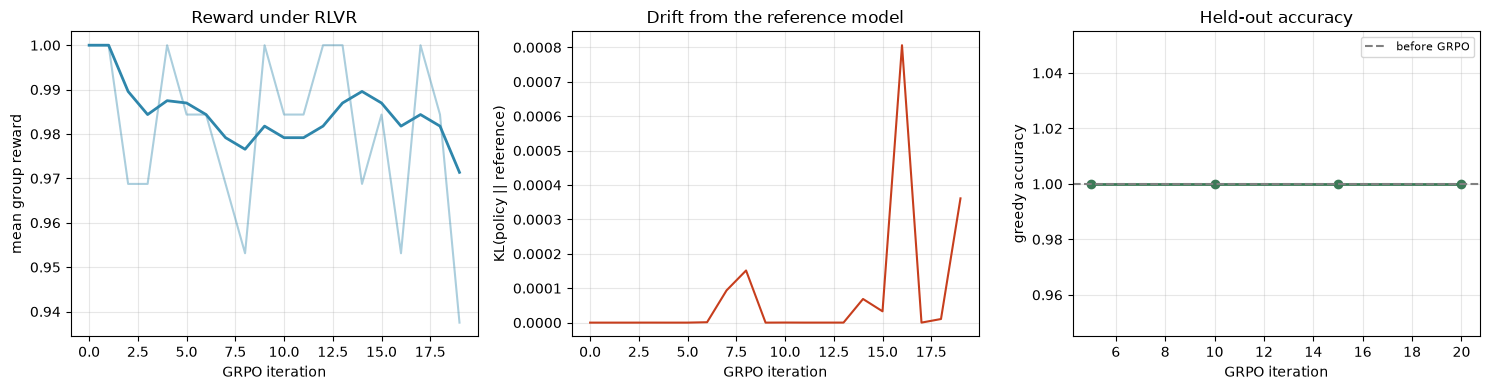

KL stays small -- the policy improves without drifting far from the
reference, which is what the beta term is for. Remove it and the policy
will happily wander into degenerate high-reward text.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rewards = [h['reward'] for h in history]
axes[0].plot(rewards, color='#2E86AB', alpha=0.4)
window = 5
smooth = [sum(rewards[max(0,i-window):i+1])/len(rewards[max(0,i-window):i+1])
          for i in range(len(rewards))]
axes[0].plot(smooth, color='#2E86AB', lw=2)
axes[0].set_xlabel('GRPO iteration')
axes[0].set_ylabel('mean group reward')
axes[0].set_title('Reward under RLVR')
axes[0].grid(alpha=0.3)

axes[1].plot([h['kl'] for h in history], color='#C73E1D', lw=1.5)
axes[1].set_xlabel('GRPO iteration')
axes[1].set_ylabel('KL(policy || reference)')
axes[1].set_title('Drift from the reference model')
axes[1].grid(alpha=0.3)

marked = [(i+1, h['accuracy']) for i, h in enumerate(history) if 'accuracy' in h]
axes[2].plot([m[0] for m in marked], [m[1] for m in marked], 'o-',
             color='#3B7A57', lw=2)
axes[2].axhline(base_acc, ls='--', color='gray', label='before GRPO')
axes[2].set_xlabel('GRPO iteration')
axes[2].set_ylabel('greedy accuracy')
axes[2].set_title('Held-out accuracy')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("KL stays small -- the policy improves without drifting far from the")
print("reference, which is what the beta term is for. Remove it and the policy")
print("will happily wander into degenerate high-reward text.")

### Why the advantage must be group-relative

A quick ablation to show the group baseline is doing real work. Replace the group-relative
advantage with the raw reward and watch the gradient signal degrade: without a baseline,
*every* sample in a group where all answers were correct gets a positive push, including the
ones that were merely lucky.

In [17]:
print("Advantage computation on a group of 8, rewards = [1,1,0,1,0,0,1,0]:\n")
rewards = torch.tensor([1., 1., 0., 1., 0., 0., 1., 0.])

raw = rewards
centred = rewards - rewards.mean()
normalized = (rewards - rewards.mean()) / (rewards.std() + 1e-6)

print(f"{'sample':>7} {'reward':>8} {'raw adv':>9} {'centred':>9} {'GRPO':>9}")
print("-" * 46)
for i in range(8):
    print(f"{i:>7} {rewards[i]:>8.0f} {raw[i]:>9.2f} "
          f"{centred[i]:>9.2f} {normalized[i]:>9.2f}")

print("\nWith raw reward, failures get advantage 0 -- no gradient at all, so the")
print("model never learns what NOT to do. Centring gives failures a negative")
print("push. Normalizing additionally makes the step size independent of how")
print("hard the prompt was.\n")

print("The degenerate case worth knowing: if all G samples get the SAME reward,")
print("std = 0 and every advantage is 0 -- the group contributes no gradient.")
print("That is why GRPO implementations filter out all-correct and all-wrong")
print("groups, and why problem difficulty has to be matched to model ability.")

all_correct = torch.ones(8)
print(f"all-correct group advantages: "
      f"{((all_correct - all_correct.mean())/(all_correct.std()+1e-6)).tolist()[:4]}...")

Advantage computation on a group of 8, rewards = [1,1,0,1,0,0,1,0]:

 sample   reward   raw adv   centred      GRPO
----------------------------------------------
      0        1      1.00      0.50      0.94
      1        1      1.00      0.50      0.94
      2        0      0.00     -0.50     -0.94
      3        1      1.00      0.50      0.94
      4        0      0.00     -0.50     -0.94
      5        0      0.00     -0.50     -0.94
      6        1      1.00      0.50      0.94
      7        0      0.00     -0.50     -0.94

With raw reward, failures get advantage 0 -- no gradient at all, so the
model never learns what NOT to do. Centring gives failures a negative
push. Normalizing additionally makes the step size independent of how
hard the prompt was.

The degenerate case worth knowing: if all G samples get the SAME reward,
std = 0 and every advantage is 0 -- the group contributes no gradient.
That is why GRPO implementations filter out all-correct and all-wrong
groups, and 

### Process reward changes what gets learned

Section 4 found that a meaningful share of correct answers came from flawed reasoning.
Outcome-only RLVR will reinforce those. Let's compare training against each reward.

In [18]:
def run_grpo(reward_fn, iterations=14, label=""):
    torch.manual_seed(0)
    pol = copy.deepcopy(base_for_rl)
    ref = copy.deepcopy(base_for_rl)
    for p in ref.parameters():
        p.requires_grad = False
    ref.eval()
    opt = torch.optim.AdamW(pol.parameters(), lr=2e-5)
    for _ in range(iterations):
        pol.eval()
        grpo_step(pol, ref, opt, num_ops=8, group_size=8, num_prompts=8,
                  beta=0.02, reward_fn=reward_fn)

    # Measure both answer accuracy AND reasoning quality
    rng = random.Random(4242)
    acc = proc = 0
    trials = 100
    for _ in range(trials):
        s, o = make_problem(8, rng)
        emitted = generate_trace(pol, s, o, temperature=0.0)
        acc += outcome_reward(s, o, emitted)
        proc += process_reward(s, o, emitted)
    print(f"  {label:<22} answer {acc/trials:.1%}   step correctness {proc/trials:.1%}")
    return acc / trials, proc / trials


start_time = time.time()
print("GRPO with different reward functions:\n")
run_grpo(outcome_reward, label="outcome reward only")
run_grpo(process_reward, label="process reward")
run_grpo(lambda s, o, e: 0.5 * outcome_reward(s, o, e) + 0.5 * process_reward(s, o, e),
         label="outcome + process")
print(f"\nElapsed {time.time()-start_time:.0f}s")
print("\nProcess reward pushes step correctness up, which is what you want if")
print("the reasoning is going to be read by a human or reused by another step.")

GRPO with different reward functions:



  outcome reward only    answer 100.0%   step correctness 100.0%


  process reward         answer 100.0%   step correctness 100.0%


  outcome + process      answer 100.0%   step correctness 100.0%

Elapsed 5s

Process reward pushes step correctness up, which is what you want if
the reasoning is going to be read by a human or reused by another step.


## 7. Failure modes

RLVR works, and it fails in characteristic ways. All of these are documented in the R1 report
and in production post-mortems.

**Overthinking.** RL rewards correctness, not brevity, so chains grow. R1-Zero's response
length increased steadily throughout training — sometimes usefully, sometimes as rambling.
Fixes: length penalties, budget forcing, or training the model to respect an explicit thinking
budget.

**Reward hacking.** The policy optimizes the *checker*, not the task. If the verifier accepts
a correct final answer, the model may learn to guess it and produce decorative reasoning.
Section 4 measured exactly this gap.

**Language mixing.** R1-Zero began mixing languages mid-chain — the reward never asked for
monolingual output. DeepSeek added a language-consistency reward for R1.

**CoT unfaithfulness.** The most important one for anyone relying on reasoning traces. The
emitted chain need not describe the computation the model actually performed. Models have
been shown to reach an answer, then construct a plausible-looking justification — and to be
influenced by hints they never mention. **A reasoning trace is not an audit log.**

**Diminishing headroom.** Test-time scaling is logarithmic. Each doubling of samples buys
less, and you eventually hit the model's ceiling: if it cannot solve a problem in 1000
samples, sampling 10,000 rarely helps.

In [19]:
# Chain length under RL: does it grow?
@torch.no_grad()
def mean_chain_length(model, num_ops, trials=50, temperature=1.0):
    """How many tokens before the model emits its answer marker."""
    rng = random.Random(555)
    lengths = []
    for _ in range(trials):
        s, o = make_problem(num_ops, rng)
        emitted = generate_trace(model, s, o, temperature)
        lengths.append(
            emitted.index('|') if '|' in emitted else len(emitted)
        )
    return sum(lengths) / len(lengths)


print(f"mean reasoning length before the answer marker (ideal = {8}):")
print(f"  before GRPO: {mean_chain_length(base_for_rl, 8):.2f}")
print(f"  after GRPO:  {mean_chain_length(policy, 8):.2f}")
print("\n(Our task has a fixed correct chain length, so there is little room to")
print("ramble. On open-ended math the growth is dramatic and needs managing.)")

mean reasoning length before the answer marker (ideal = 8):


  before GRPO: 8.00


  after GRPO:  8.02

(Our task has a fixed correct chain length, so there is little room to
ramble. On open-ended math the growth is dramatic and needs managing.)


In [20]:
# Test-time scaling saturates
print("\nDiminishing returns, measured:\n")
print(f"{'N':>5} {'accuracy':>10} {'gain over previous':>20}")
print("-" * 38)
prev = None
for n, acc in zip(sample_counts, sc_acc):
    gain = f"{acc-prev:+.1%}" if prev is not None else "-"
    print(f"{n:>5} {acc:>9.1%} {gain:>20}")
    prev = acc

print("\nEach doubling buys less than the last. Test-time compute is a real")
print("lever with a logarithmic exchange rate -- not a substitute for a")
print("better model, and it cannot exceed what the model can ever produce.")


Diminishing returns, measured:

    N   accuracy   gain over previous
--------------------------------------
    1    100.0%                    -
    2    100.0%                +0.0%
    4    100.0%                +0.0%
    8    100.0%                +0.0%
   16    100.0%                +0.0%

Each doubling buys less than the last. Test-time compute is a real
lever with a logarithmic exchange rate -- not a substitute for a
better model, and it cannot exceed what the model can ever produce.


## 8. Where this sits in the pipeline

The full modern recipe, with this notebook's contribution in bold:

```
pretrain  ->  SFT (NB 12)  ->  preference alignment (NB 13)
                                        |
                                        v
                          long-CoT SFT  ->  RLVR / GRPO (this notebook)
                                        |
                                        v
                              distill into smaller models
```

Two points worth stating explicitly.

**RLVR and RLHF are complementary, not competing.** RLHF makes a model helpful and
appropriately behaved; RLVR makes it correct on verifiable problems. Production models get
both.

**Distillation transfers reasoning cheaply.** R1's most practically significant result was
arguably not R1 itself but that fine-tuning small models on R1's *long CoT traces* produced
reasoning ability far above what RL on those small models achieved directly. Reasoning is
easier to copy than to discover — which is why capable reasoning models proliferated so fast
after R1's traces became available.

| | RLHF (NB 13) | RLVR (NB 18) |
|---|---|---|
| Optimizes | Human preference | Verifiable correctness |
| Reward | Learned model (Bradley-Terry) | Automatic checker |
| Algorithm | PPO (needs a value network) | GRPO (group baseline) |
| Main risk | Reward model gaming | Checker gaming, overthinking |
| Domain limit | None | Only verifiable domains |
| Output | Helpful, well-behaved | Correct, longer-thinking |

## Summary

**The theoretical basis.** A Transformer has fixed depth, so a single forward pass affords a
bounded number of sequential composition steps. We built a task requiring `k` ordered steps
and confirmed the direct model collapses toward chance as `k` grows — while the *same
architecture* with Chain of Thought holds up, because each emitted token needs only one step.
The ablation delivered a sharper lesson than expected: at this scale neither more depth nor
more width rescued the direct model, because representability is not learnability — SGD does
not reliably find the layer-as-a-step circuit even when the depth exists. CoT sidesteps the
whole issue by externalizing each step as a token, converting a hard-to-learn internal circuit
into a training-data format and making the step count a runtime choice.

**Spending compute at inference.** Self-consistency (majority vote over `N` samples) improves
accuracy roughly logarithmically in `N`. A verifier does better than voting, and a *process*
verifier beats an *outcome* verifier — because it can tell correct reasoning from a lucky
guess. We measured a substantial share of correct answers arriving through flawed traces.

**RLVR.** Math and code have automatic checkers, so no reward model is needed. That removes
reward-model gaming and the labelling cost — at the price of only working where verification
is possible. STaR (sample, filter on verification, fine-tune) is a strong baseline needing no
RL at all.

**GRPO.** Replaces PPO's value network with the mean reward of a sampled *group*:
`A_i = (r_i − mean(r)) / std(r)`. Half the memory, fewer moving parts. The group baseline is
essential — with raw rewards, failures produce no gradient. And an all-correct or all-wrong
group produces no gradient either, which is why difficulty must be matched to ability.

### Key Takeaways

1. **CoT rents serial computation.** The limit it lifts is sequential — a fixed-depth forward
   pass affords bounded serial steps — and CoT externalizes each step as a token. Note the
   subtlety: at small scale even adding depth does not rescue the direct model, because the
   layer-as-a-step circuit is representable but not reliably learnable. CoT avoids needing it.
2. **Test-time compute is a real scaling axis with a logarithmic exchange rate.** Useful, and
   not a substitute for a better model.
3. **Verifiers beat voting; process beats outcome.** Outcome-only reward reinforces reasoning
   that is wrong but lucky.
4. **RLVR's power and its limit are the same fact:** it needs an automatic checker. Hence the
   concentration of progress in math and code.
5. **GRPO removes the value network** by using a group of samples as its own baseline.
6. **A group with zero reward variance gives zero gradient.** Filter degenerate groups.
7. **A reasoning trace is not an audit log.** CoT need not reflect the actual computation —
   do not treat it as an explanation.
8. **Reasoning distills unusually well.** Training small models on strong traces beats running
   RL on those small models.

### Self-check

- Why can a small Transformer not solve a 12-step sequential problem in one forward pass, no
  matter how wide it is?
- The ablation found that neither depth nor width rescued the direct model. What does that
  reveal about the difference between representability and learnability?
- What does CoT change about *where* the computation happens?
- Why does a process verifier outperform an outcome verifier at best-of-N selection?
- What does RLVR remove from the RLHF pipeline, and what does it give up in exchange?
- Write down GRPO's advantage formula. What does it replace, and what does it save?
- A GRPO group returns rewards `[1,1,1,1]`. What is the gradient, and why is that a problem?
- Your model's reasoning trace mentions no hint, but its answer changed when you added one.
  What does that tell you about the trace?

### What's next

Notebook 19 covers **efficiency** — quantization, distillation, and pruning: how the models
built in 14–18 get small enough and fast enough to actually deploy.

### References

- Wei et al., 2022 — [Chain-of-Thought Prompting](https://arxiv.org/abs/2201.11903)
- Wang et al., 2022 — [Self-Consistency Improves CoT Reasoning](https://arxiv.org/abs/2203.11171)
- Nye et al., 2021 — [Show Your Work: Scratchpads](https://arxiv.org/abs/2112.00114)
- Merrill & Sabharwal, 2023 — [The Expressive Power of Transformers with Chain of Thought](https://arxiv.org/abs/2310.07923) (the depth argument, formally)
- Feng et al., 2023 — [Towards Revealing the Mystery behind CoT](https://arxiv.org/abs/2305.15408)
- Cobbe et al., 2021 — [Training Verifiers to Solve Math Word Problems](https://arxiv.org/abs/2110.14168) (GSM8K, ORM)
- Lightman et al., 2023 — [Let's Verify Step by Step](https://arxiv.org/abs/2305.20050) (PRM)
- Zelikman et al., 2022 — [STaR: Self-Taught Reasoner](https://arxiv.org/abs/2203.14465)
- Shao et al., 2024 — [DeepSeekMath](https://arxiv.org/abs/2402.03300) (**GRPO**)
- DeepSeek-AI, 2025 — [DeepSeek-R1](https://arxiv.org/abs/2501.12948) (RLVR, the aha moment, distillation)
- Snell et al., 2024 — [Scaling LLM Test-Time Compute Optimally](https://arxiv.org/abs/2408.03314)
- Muennighoff et al., 2025 — [s1: Simple Test-Time Scaling](https://arxiv.org/abs/2501.19393) (budget forcing)
- Turpin et al., 2023 — [Language Models Don't Always Say What They Think](https://arxiv.org/abs/2305.04388) (CoT unfaithfulness)
- Lanham et al., 2023 — [Measuring Faithfulness in Chain-of-Thought Reasoning](https://arxiv.org/abs/2307.13702)